In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sales_data = pd.read_csv('sales_data.csv')

In [3]:
sales_data.head()

,Date,Region,Product,Units,Revenue
0,2024-01-01,North,Electronics,5,1298.43
1,2024-01-01,South,Electronics,3,737.77
2,2024-01-01,North,Groceries,3,36.37
3,2024-01-01,South,Groceries,2,26.18
4,2024-01-01,North,Groceries,2,30.30


In [7]:
# conversting string dates to actual dates
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

In [5]:
sales_data

,Date,Region,Product,Units,Revenue
0,2024-01-01,North,Electronics,5,1298.43
1,2024-01-01,South,Electronics,3,737.77
2,2024-01-01,North,Groceries,3,36.37
3,2024-01-01,South,Groceries,2,26.18
4,2024-01-01,North,Groceries,2,30.30
...,...,...,...,...,...
1859,2024-12-30,South,Toys,3,96.18
1860,2024-12-31,South,Groceries,1,19.41
1861,2024-12-31,South,Clothing,1,54.44
1862,2024-12-31,South,Electronics,3,1013.46


In [8]:
#extracting the month
sales_data['Month'] = sales_data['Date'].dt.month

In [9]:
# groupby + sum
monthly_revenue = sales_data.groupby('Month')['Revenue'].sum()
region_revenue = sales_data.groupby('Region')['Revenue'].sum()
product_revenue = sales_data.groupby('Product')['Revenue'].sum()

In [12]:
monthly_revenue

,Revenue
Month,
1,59479.24
2,44449.53
3,54520.35
4,55150.66
5,54075.12
6,54470.55
7,47671.20
8,65509.49
9,42641.61


In [13]:
region_revenue

,Revenue
Region,
East,164958.25
North,169393.18
South,168224.04
West,162628.54


In [14]:
product_revenue

,Revenue
Product,
Clothing,64481.04
Electronics,392332.04
Furniture,167516.77
Groceries,26407.86
Toys,14466.30


In [17]:
sales_data.head()

,Date,Region,Product,Units,Revenue,Month
0,2024-01-01,North,Electronics,5,1298.43,1
1,2024-01-01,South,Electronics,3,737.77,1
2,2024-01-01,North,Groceries,3,36.37,1
3,2024-01-01,South,Groceries,2,26.18,1
4,2024-01-01,North,Groceries,2,30.30,1


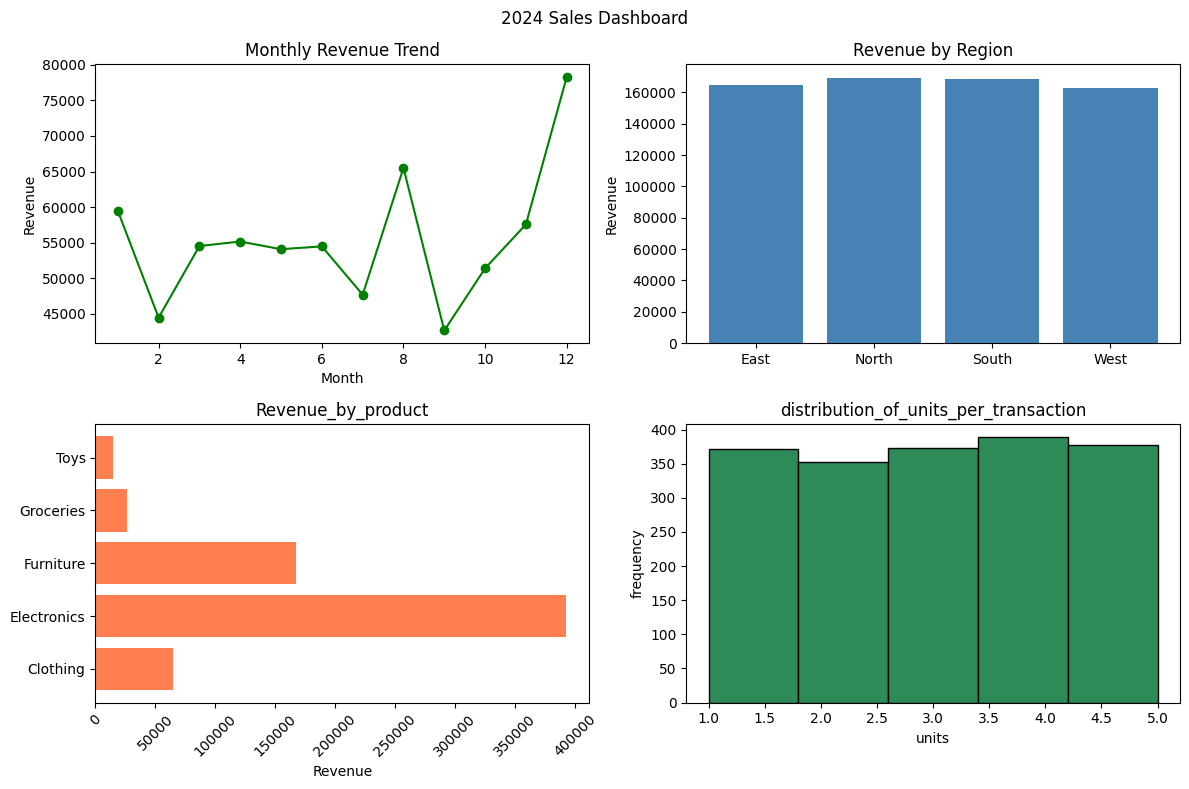

In [45]:
from matplotlib import colorbar
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
fig.suptitle('2024 Sales Dashboard')

#1
axs[0, 0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color="green")
axs[0, 0].set_title("Monthly Revenue Trend")
axs[0, 0].set_xlabel("Month")
axs[0, 0].set_ylabel("Revenue")

#2
axs[0,1].bar(region_revenue.index, region_revenue.values, color='Steelblue')
axs[0,1].set_title("Revenue by Region")
axs[0,1].set_ylabel("Revenue")

#3
axs[1,0].barh(product_revenue.index, product_revenue.values, color="coral")
axs[1,0].set_title("Revenue_by_product")
axs[1,0].set_xlabel("Revenue")
# new
axs[1,0].tick_params(axis='x', labelrotation=45)

#4
axs[1,1].hist(sales_data['Units'], bins=5, color='seagreen', edgecolor='black')
axs[1,1].set_title("distribution_of_units_per_transaction")
axs[1,1].set_xlabel("units")
axs[1,1].set_ylabel("frequency")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150)

fig.show()
